## Fase 2B: Entendimento do Índice NDVI e EVI

Este notebook apresenta um estudo sobre o índice NDVI (Normalized Difference Vegetation Index) e EVI (Enhanced Vegetation Index), entendendo como são calculados e como podem ser utilizados para monitorar o desenvolvimento da vegetação.

In [7]:
# Célula de configuração para execução independente
# Esta célula permite que o notebook seja executado independentemente

# Verificar se as bibliotecas básicas já estão importadas
import os
import sys

# Adicionar o diretório notebooks ao caminho de busca se necessário
notebooks_dir = os.path.dirname(os.path.abspath("__file__"))
if notebooks_dir not in sys.path:
    sys.path.append(notebooks_dir)

# Tentar importar o módulo utils, se falhar, importar bibliotecas individualmente
try:
    import utils
    utils.setup_visualization()
    print("Módulo utils importado com sucesso.")
except ImportError:
    print("Importando bibliotecas individualmente...")
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import warnings
    from IPython.display import display, HTML, Image as IPImage
    
    # Configurações de visualização
    warnings.filterwarnings('ignore')
    plt.style.use('fivethirtyeight')
    sns.set(style="whitegrid")
    pd.set_option('display.max_columns', None)
    print("Bibliotecas importadas individualmente.")

%matplotlib inline

Visualization settings configured successfully.
Módulo utils importado com sucesso.


## Entendimento do Índice NDVI

O NDVI (Normalized Difference Vegetation Index) é um índice vegetativo que mede a diferença entre a reflectância no infravermelho próximo (NIR) e a reflectância no vermelho (RED), normalizada pela soma dessas reflectâncias:

$$NDVI = \frac{NIR - RED}{NIR + RED}$$

O NDVI varia de -1 a 1, onde:
- Valores próximos a 1 indicam vegetação densa e saudável
- Valores próximos a 0 indicam solo exposto ou vegetação esparsa
- Valores negativos indicam água, neve, nuvens ou áreas urbanas

### Princípio Físico do NDVI

O princípio físico por trás do NDVI está relacionado à forma como a vegetação interage com a radiação eletromagnética. A vegetação saudável absorve fortemente a radiação na região do vermelho (RED) do espectro visível, devido à presença de clorofila, e reflete fortemente a radiação na região do infravermelho próximo (NIR), devido à estrutura celular das folhas.

Assim, quanto maior a diferença entre a reflectância no NIR e no RED, maior a quantidade de vegetação saudável presente. O NDVI normaliza essa diferença pela soma das reflectâncias, o que ajuda a compensar diferenças de iluminação e permite a comparação entre diferentes imagens.

### Utilidade do NDVI

O NDVI é amplamente utilizado para:

1. **Monitoramento da Vegetação:** Permite acompanhar o desenvolvimento da vegetação ao longo do tempo, identificando períodos de crescimento, senescência e colheita.

2. **Detecção de Mudanças:** Permite identificar mudanças na cobertura vegetal, como desmatamento, queimadas, ou conversão de áreas naturais em áreas agrícolas.

3. **Avaliação de Produtividade:** Pode ser utilizado como indicador da produtividade agrícola, uma vez que está relacionado à biomassa e à atividade fotossintética da vegetação.

4. **Monitoramento de Secas:** Permite identificar áreas afetadas por secas, uma vez que a vegetação estressada por falta de água apresenta valores mais baixos de NDVI.

5. **Identificação de Culturas:** Diferentes culturas apresentam padrões temporais de NDVI distintos, o que permite sua identificação.

6. **Mapeamento de Uso e Cobertura da Terra:** Auxilia na classificação de diferentes tipos de cobertura vegetal, como florestas, pastagens, áreas agrícolas, etc.

7. **Estudos de Mudanças Climáticas:** Permite monitorar os efeitos das mudanças climáticas na vegetação, como alterações na fenologia (ciclo de vida) das plantas.

8. **Planejamento Agrícola:** Auxilia no planejamento de atividades agrícolas, como plantio, irrigação, aplicação de fertilizantes e colheita.

### Limitações do NDVI

Apesar de sua ampla utilização, o NDVI apresenta algumas limitações:

1. **Saturação:** O NDVI tende a saturar em áreas com alta densidade de vegetação, o que limita sua capacidade de diferenciar níveis de biomassa em florestas densas, por exemplo.

2. **Sensibilidade a Condições Atmosféricas:** O NDVI é sensível a condições atmosféricas, como nuvens, aerossóis e vapor d'água, o que pode afetar sua precisão.

3. **Influência do Solo:** Em áreas com vegetação esparsa, o NDVI pode ser influenciado pela reflectância do solo, o que pode levar a interpretações errôneas.

4. **Sensibilidade a Variações Sazonais:** O NDVI varia naturalmente ao longo do ano devido a mudanças sazonais na vegetação, o que pode dificultar a detecção de mudanças reais na cobertura vegetal.

5. **Limitações em Áreas Urbanas:** O NDVI não é adequado para monitorar a vegetação em áreas urbanas, devido à presença de superfícies artificiais que podem afetar os valores do índice.

Para superar algumas dessas limitações, outros índices vegetativos foram desenvolvidos, como o EVI (Enhanced Vegetation Index), que é menos sensível a condições atmosféricas e à influência do solo.

## Entendimento do Índice EVI

O EVI (Enhanced Vegetation Index) é um índice vegetativo desenvolvido para melhorar a sensibilidade em áreas com alta biomassa e reduzir a influência da atmosfera e do solo. Sua fórmula é:

$$EVI = G \times \frac{NIR - RED}{NIR + C1 \times RED - C2 \times BLUE + L}$$

Onde:
- G é um fator de ganho (geralmente 2.5)
- C1 e C2 são coeficientes de correção atmosférica (geralmente 6 e 7.5, respectivamente)
- L é um fator de ajuste do solo (geralmente 1)
- NIR, RED e BLUE são as reflectâncias no infravermelho próximo, vermelho e azul, respectivamente

O EVI varia de -1 a 1, assim como o NDVI, mas é menos propenso a saturação em áreas com alta biomassa e é menos sensível a condições atmosféricas e à influência do solo.

### Comparação entre NDVI e EVI

| Característica | NDVI | EVI |
|----------------|------|-----|
| Sensibilidade a alta biomassa | Tende a saturar | Menos propenso a saturação |
| Sensibilidade a condições atmosféricas | Alta | Baixa |
| Influência do solo | Alta | Baixa |
| Complexidade de cálculo | Simples | Complexo |
| Disponibilidade de dados históricos | Alta | Média |

Na plataforma SATVeg, ambos os índices estão disponíveis, permitindo a escolha do mais adequado para cada análise.

## Interpretação dos Valores de NDVI e EVI

A interpretação dos valores de NDVI e EVI depende do tipo de cobertura vegetal e da região estudada. No entanto, alguns valores de referência podem ser utilizados como guia:

### NDVI

- **< 0:** Água, neve, nuvens, áreas urbanas
- **0 - 0.2:** Solo exposto, áreas urbanas, vegetação muito esparsa
- **0.2 - 0.4:** Vegetação esparsa, pastagens, culturas em estágio inicial ou final
- **0.4 - 0.6:** Vegetação moderada, culturas em desenvolvimento
- **0.6 - 0.8:** Vegetação densa, culturas em pleno desenvolvimento, florestas
- **0.8 - 1.0:** Vegetação muito densa, florestas tropicais

### EVI

Os valores de EVI são geralmente mais baixos que os de NDVI, mas seguem uma interpretação semelhante:

- **< 0:** Água, neve, nuvens, áreas urbanas
- **0 - 0.2:** Solo exposto, áreas urbanas, vegetação muito esparsa
- **0.2 - 0.4:** Vegetação esparsa a moderada
- **0.4 - 0.6:** Vegetação moderada a densa
- **> 0.6:** Vegetação muito densa

É importante ressaltar que esses valores são apenas referências e podem variar dependendo da região, do tipo de vegetação, da época do ano e das condições ambientais.

## Aplicações do NDVI e EVI na Agricultura

Na agricultura, o NDVI e o EVI são utilizados para diversas aplicações, como:

### 1. Monitoramento do Desenvolvimento das Culturas

Os índices vegetativos permitem acompanhar o desenvolvimento das culturas ao longo do ciclo, identificando as fases de crescimento, floração, frutificação e senescência. Isso auxilia no planejamento de atividades agrícolas, como irrigação, aplicação de fertilizantes e colheita.

### 2. Detecção de Estresse Hídrico

A vegetação estressada por falta de água apresenta valores mais baixos de NDVI e EVI. Assim, esses índices podem ser utilizados para identificar áreas com déficit hídrico, auxiliando no manejo da irrigação.

### 3. Identificação de Pragas e Doenças

Pragas e doenças podem afetar a saúde da vegetação, reduzindo os valores de NDVI e EVI. A detecção precoce dessas anomalias permite a adoção de medidas de controle antes que os danos se tornem significativos.

### 4. Estimativa de Produtividade

Existe uma relação entre os valores de NDVI/EVI e a produtividade das culturas. Assim, esses índices podem ser utilizados para estimar a produtividade antes da colheita, auxiliando no planejamento logístico e comercial.

### 5. Agricultura de Precisão

Os índices vegetativos podem ser utilizados para identificar variações espaciais na lavoura, permitindo a aplicação de insumos (fertilizantes, defensivos, água) de forma diferenciada, de acordo com as necessidades de cada área. Isso otimiza o uso de recursos e reduz o impacto ambiental.

## Exemplo de Análise de NDVI/EVI

Vamos criar um exemplo simples de como os valores de NDVI e EVI variam ao longo do ano para diferentes tipos de cobertura vegetal. Este é um exemplo fictício para fins didáticos.

In [8]:
# Criando dados fictícios de NDVI e EVI para diferentes tipos de cobertura vegetal
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# Floresta tropical (valores altos e estáveis)
ndvi_floresta = [0.85, 0.84, 0.86, 0.87, 0.85, 0.83, 0.82, 0.81, 0.83, 0.84, 0.85, 0.86]
evi_floresta = [0.65, 0.64, 0.66, 0.67, 0.65, 0.63, 0.62, 0.61, 0.63, 0.64, 0.65, 0.66]

# Agricultura (padrão sazonal)
ndvi_agricultura = [0.3, 0.4, 0.6, 0.7, 0.8, 0.7, 0.5, 0.3, 0.2, 0.2, 0.3, 0.3]
evi_agricultura = [0.2, 0.3, 0.5, 0.6, 0.7, 0.6, 0.4, 0.2, 0.1, 0.1, 0.2, 0.2]

# Pastagem (valores moderados com sazonalidade)
ndvi_pastagem = [0.5, 0.55, 0.6, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.45, 0.5, 0.5]
evi_pastagem = [0.4, 0.45, 0.5, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.35, 0.4, 0.4]

# Área urbana (valores baixos e estáveis)
ndvi_urbana = [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
evi_urbana = [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]

# Água (valores negativos)
ndvi_agua = [-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2]
evi_agua = [-0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1]

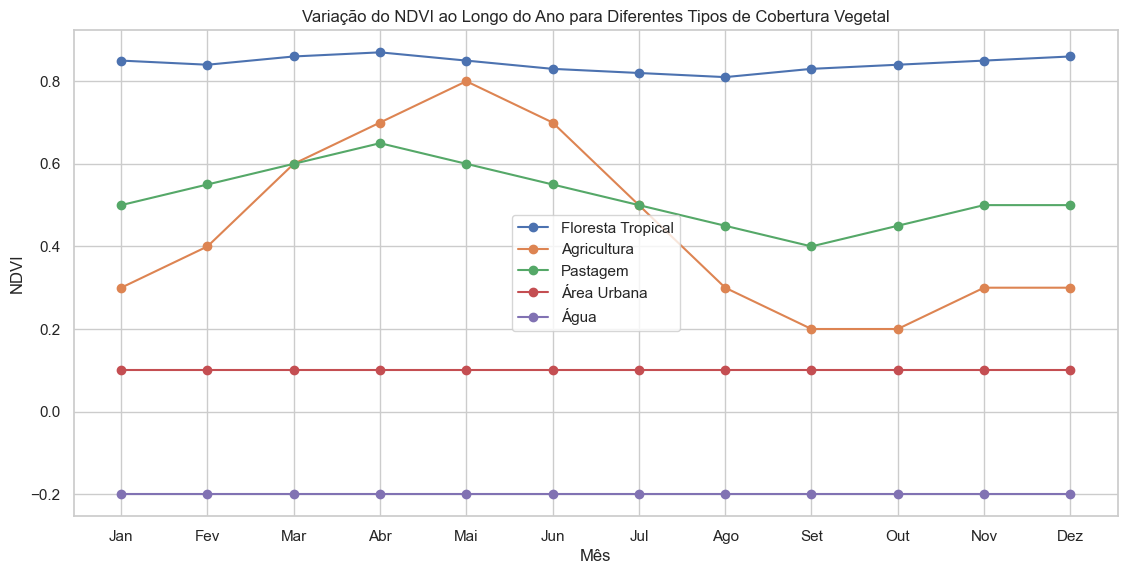

In [9]:
# Importação adicionada para garantir que plt esteja disponível
import matplotlib.pyplot as plt

# Plotando os valores de NDVI para diferentes tipos de cobertura vegetal
plt.figure(figsize=(12, 6))
plt.plot(meses, ndvi_floresta, marker='o', label='Floresta Tropical')
plt.plot(meses, ndvi_agricultura, marker='o', label='Agricultura')
plt.plot(meses, ndvi_pastagem, marker='o', label='Pastagem')
plt.plot(meses, ndvi_urbana, marker='o', label='Área Urbana')
plt.plot(meses, ndvi_agua, marker='o', label='Água')
plt.title('Variação do NDVI ao Longo do Ano para Diferentes Tipos de Cobertura Vegetal')
plt.xlabel('Mês')
plt.ylabel('NDVI')
plt.grid(True)
plt.legend()
plt.show()

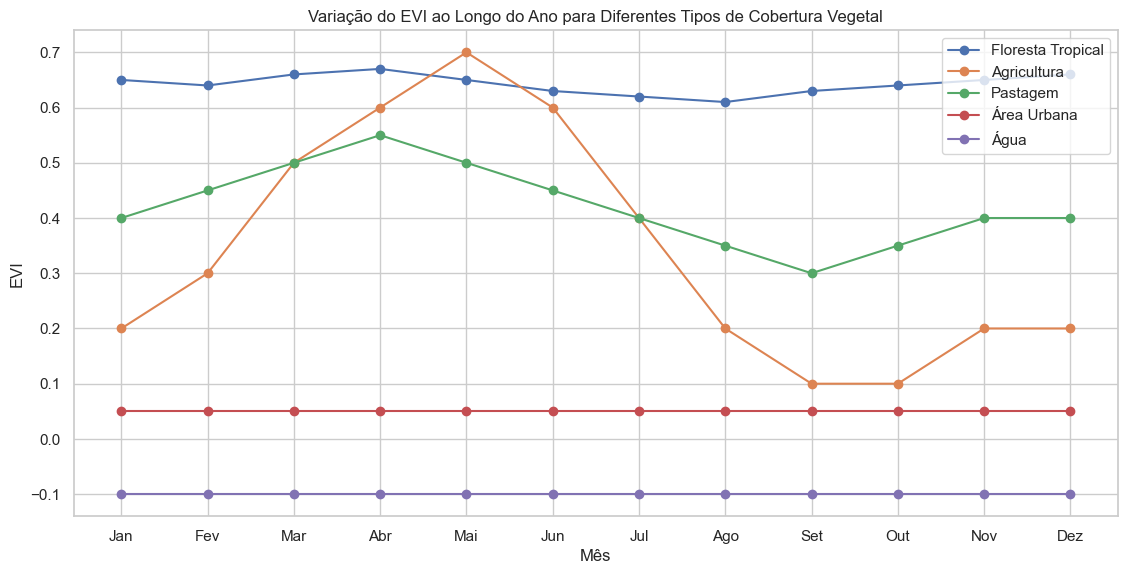

In [10]:
# Importação adicionada para garantir que plt esteja disponível
import matplotlib.pyplot as plt

# Plotando os valores de EVI para diferentes tipos de cobertura vegetal
plt.figure(figsize=(12, 6))
plt.plot(meses, evi_floresta, marker='o', label='Floresta Tropical')
plt.plot(meses, evi_agricultura, marker='o', label='Agricultura')
plt.plot(meses, evi_pastagem, marker='o', label='Pastagem')
plt.plot(meses, evi_urbana, marker='o', label='Área Urbana')
plt.plot(meses, evi_agua, marker='o', label='Água')
plt.title('Variação do EVI ao Longo do Ano para Diferentes Tipos de Cobertura Vegetal')
plt.xlabel('Mês')
plt.ylabel('EVI')
plt.grid(True)
plt.legend()
plt.show()

## Conclusão

O NDVI e o EVI são índices vegetativos amplamente utilizados para monitorar o desenvolvimento da vegetação. Eles fornecem informações valiosas sobre a saúde e o vigor da vegetação, permitindo identificar mudanças na cobertura vegetal, estimar a produtividade agrícola, detectar estresse hídrico, entre outras aplicações.

Na plataforma SATVeg, ambos os índices estão disponíveis, permitindo a escolha do mais adequado para cada análise. O NDVI é mais simples e tem uma longa série histórica, enquanto o EVI é mais robusto em relação a condições atmosféricas e à influência do solo, sendo menos propenso a saturação em áreas com alta biomassa.

A interpretação dos valores de NDVI e EVI depende do tipo de cobertura vegetal e da região estudada, mas alguns valores de referência podem ser utilizados como guia. É importante ressaltar que esses valores são apenas referências e podem variar dependendo da região, do tipo de vegetação, da época do ano e das condições ambientais.

## Próximos Passos

No próximo notebook, vamos explorar os padrões de bibliotecas e gráficos existentes na plataforma SATVeg, e aprender a definir região, latitude e longitude para análise.